 *Artificial Intelligence for Vision & NLP* &nbsp; | &nbsp;  *ATU Donegal - Postgrad Diploma in Big Data Analytics & Artificial Intelligence*

# Student Submisson 
Name           : Steven McGuire  <br>
Student Number : L00196739         <br>
Due Date       : 12/05/2026           <br>
Assignment     : CA2             <br>
Module         : AI for Vision and NLP    <br>
Course         : Postgraduate Diploma in Big Data Analytics and AI

## NLP and Vision Pipeline : High Level


This project builds a multi-modal document understanding pipeline for selected pages of the 2026 IPF Technical Rulebook. The system converts PDF pages to images, applies image preprocessing, extracts text using OCR, applies NLP preprocessing, detects document layout features, and produces structured textual and visual insights.

Although the module covers both NLP and computer vision, this workflow begins with image preprocessing because the source material is a PDF document. The extracted OCR text is then used as the input for the NLP stage.

# Initialisation


## Install packages

In [1]:
# Install all required packages from requirements.txt

import sys
!{sys.executable} -m pip install -r requirements.txt

## Imports

In [2]:
# imports
import pytesseract
import cv2
import spacy
nlp = spacy.load('en_core_web_sm')
import fitz # aka pymupdf - image processing
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from PIL import Image
import pytesseract
import spacy
import nltk
from nltk.stem import PorterStemmer
import pandas as pd
# regular expression
import re
import sys
import os
import io





In [3]:
#configuration
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

pdf_path = r"C:\Users\thela\Desktop\College Course Work\AI for Vision and NLP\CA2\2026_IPF_Technical_Rulebook.pdf"

# Section 1. Vision

## Section 1.a Image Preprocessing

In [4]:
# ============================================================
# Image Preprocessing
# Loads selected pages from the IPF Technical Rulebook PDF
# and applies OpenCV preprocessing to improve image quality
# before OCR extraction in Section 1b.
# Reference: https://www.geeksforgeeks.org/python/convert-pdf-to-image-using-python/
# ============================================================

# ------------------------------------------------------------
# Step 1 - Load selected pages from PDF
# ------------------------------------------------------------

# This document provides multimodal elements to satisfy the CA requirement as follows
PAGE_NUMBERS = [2, 4, 5, 10, 25]
PAGE_LABELS = {
    2:  "Table of Contents",
    4:  "Dense Text",
    5:  "Tables",
    10: "Mixed Content",
    25: "Diagrams and Figures"
}

pdf_document = fitz.open(pdf_path)

all_pages = []

for page in pdf_document:
    pix = page.get_pixmap(dpi=600) #I have increased this from 300dpi for higher quality output
    image = Image.open(io.BytesIO(pix.tobytes("png")))
    all_pages.append(image)

selected_pages = {pg: all_pages[pg - 1] for pg in PAGE_NUMBERS}

print(f"PDF loaded successfully. {len(all_pages)} total pages found")
print(f"Selected pages: {PAGE_NUMBERS}\n")


PDF loaded successfully. 45 total pages found
Selected pages: [2, 4, 5, 10, 25]



In [5]:
#investigate the document pages
#displaying as grayscale to see waterproof mark easier also

images = []
titles = []

for page_number in PAGE_NUMBERS:
    img = selected_pages[page_number]
    img = np.array(img)
    gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    images.append(gray_img)
    titles.append(f"Page {page_number} - {PAGE_LABELS[page_number]}")

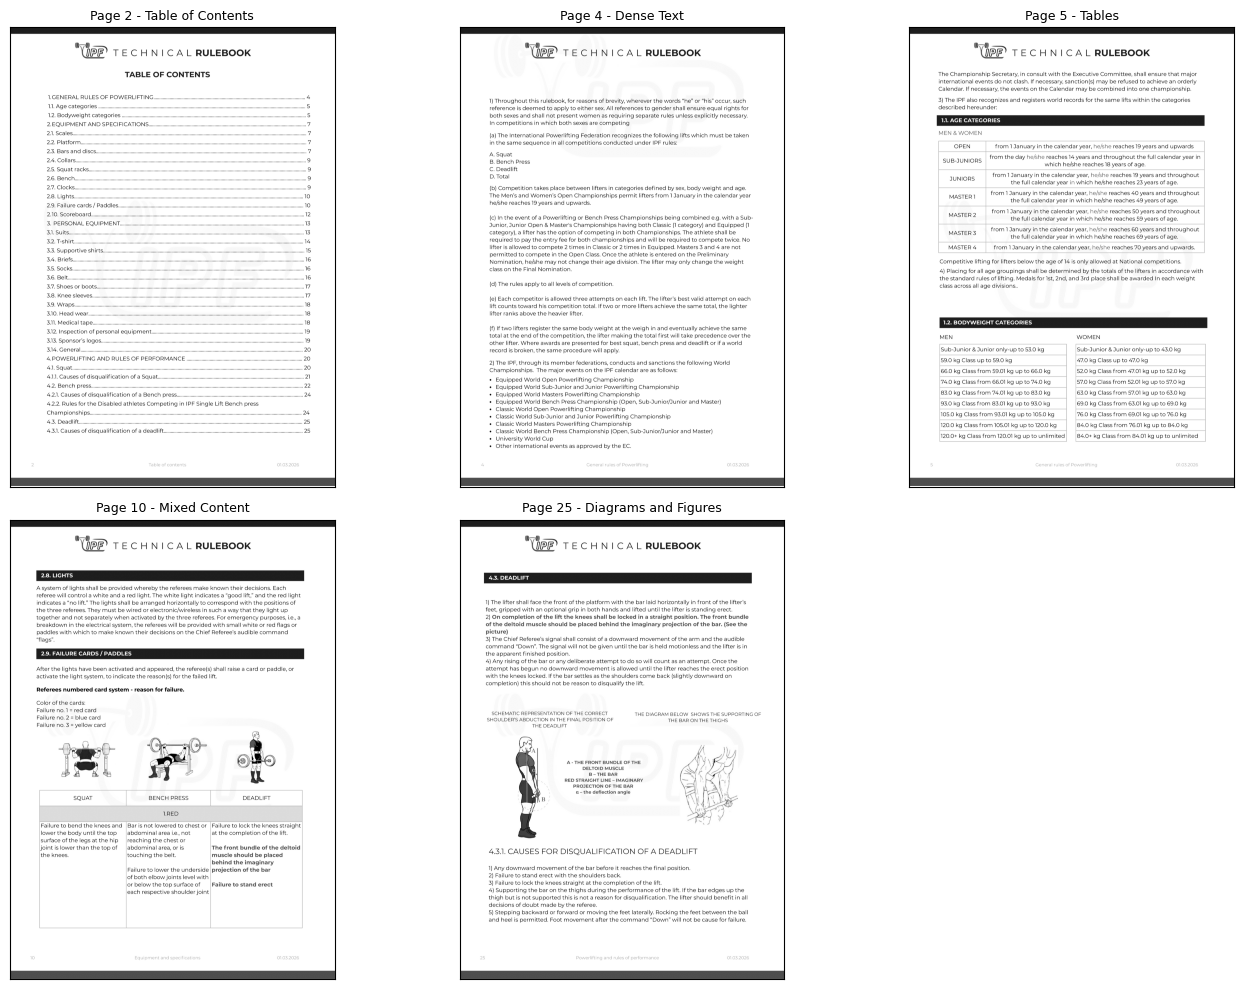

In [6]:
plt.figure(figsize=(14, 10))

for i in range(len(images)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i], fontsize=9)
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()

### Use thresholding to remove the "IPF" watermark

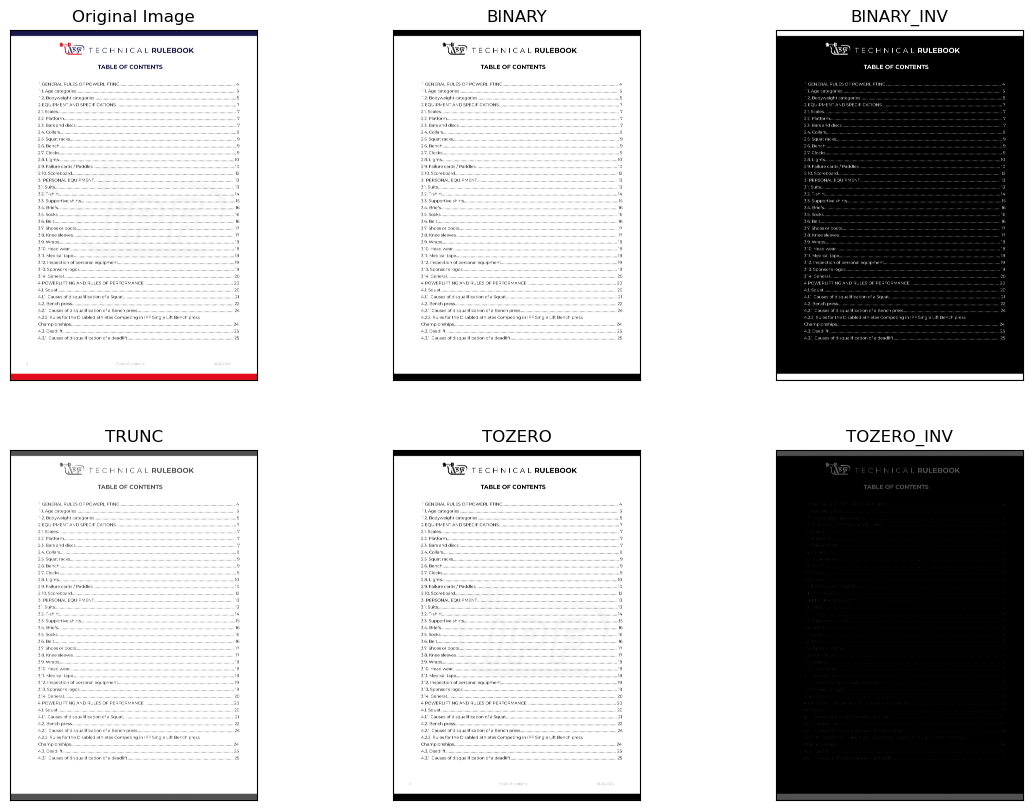

In [7]:
#Lab 6a - Image processing
img = selected_pages[2]
img = np.array(img)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Thresholding is cool
ret,thresh1 = cv2.threshold(img_gray,127,255,cv2.THRESH_BINARY)
ret,thresh2 = cv2.threshold(img_gray,127,255,cv2.THRESH_BINARY_INV)
ret,thresh3 = cv2.threshold(img_gray,127,255,cv2.THRESH_TRUNC)
ret,thresh4 = cv2.threshold(img_gray,127,255,cv2.THRESH_TOZERO)
ret,thresh5 = cv2.threshold(img_gray,127,255,cv2.THRESH_TOZERO_INV)

titles = ['Original Image','BINARY','BINARY_INV','TRUNC','TOZERO','TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]

plt.figure(figsize=(14, 10))
for i in range(6):
    plt.subplot(2,3,i+1),plt.imshow(images[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])


plt.show()


In [8]:
#binary thresholding option allows for watermark to be removed. 
#TRUNC was also an option, but the text was left lighter, whereas binary gave a more readable, bold font
#apply this to all pages and display for verification
binary_thresholded_pages = {}

for page_number in PAGE_NUMBERS:
    # Get page image from memory
    img = selected_pages[page_number]
    
    # Convert PIL image to NumPy array
    img = np.array(img)
    
    # Convert to grayscale
    img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    
    # Apply binary thresholding
    ret, thresh_binary = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)
    
    # Store result
    binary_thresholded_pages[page_number] = thresh_binary


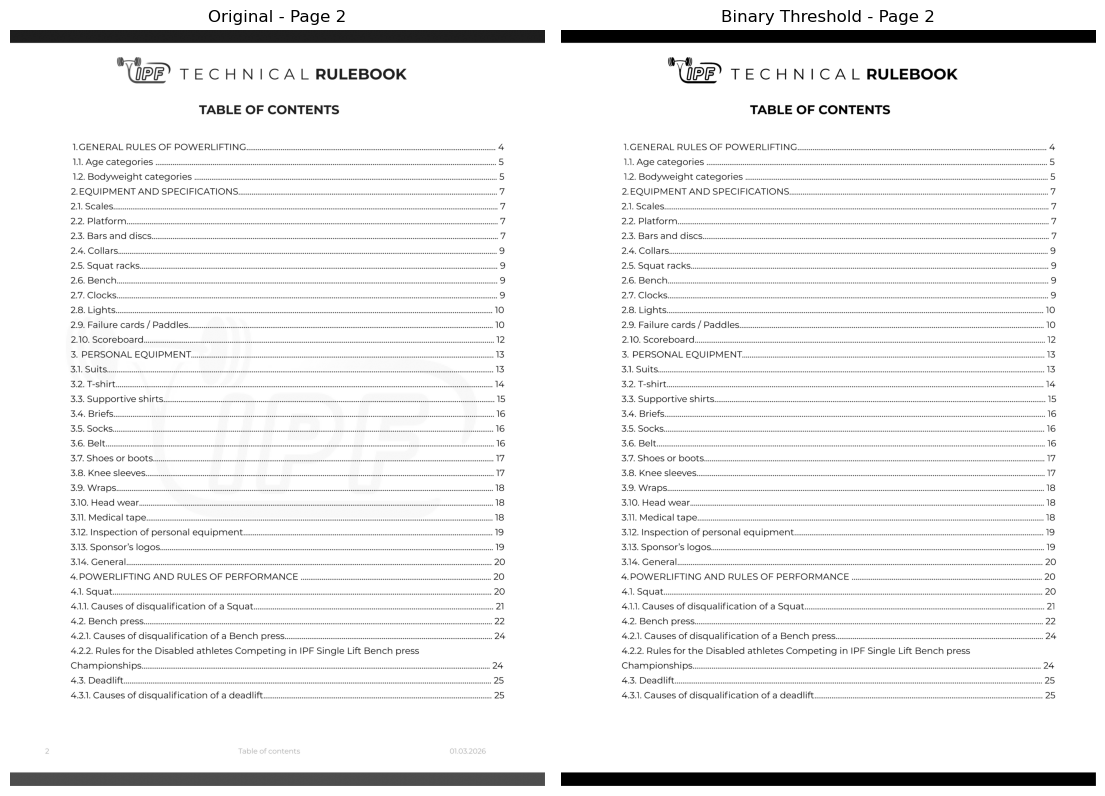

In [9]:
## Having a look at the image
page_number = 2 

# Original
img = np.array(selected_pages[page_number])
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Thresholded
thresholded_img = binary_thresholded_pages[page_number]

plt.figure(figsize=(14, 10))

plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap="gray")
plt.title(f"Original - Page {page_number}", fontsize=12)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(thresholded_img, cmap="gray")
plt.title(f"Binary Threshold - Page {page_number}", fontsize=12)
plt.axis("off")

plt.subplots_adjust(wspace=0.03)
plt.show()

#store 
preprocessed_pages = {}
preprocessed_pages[page_number] = thresholded_img


good news watermark has been removed

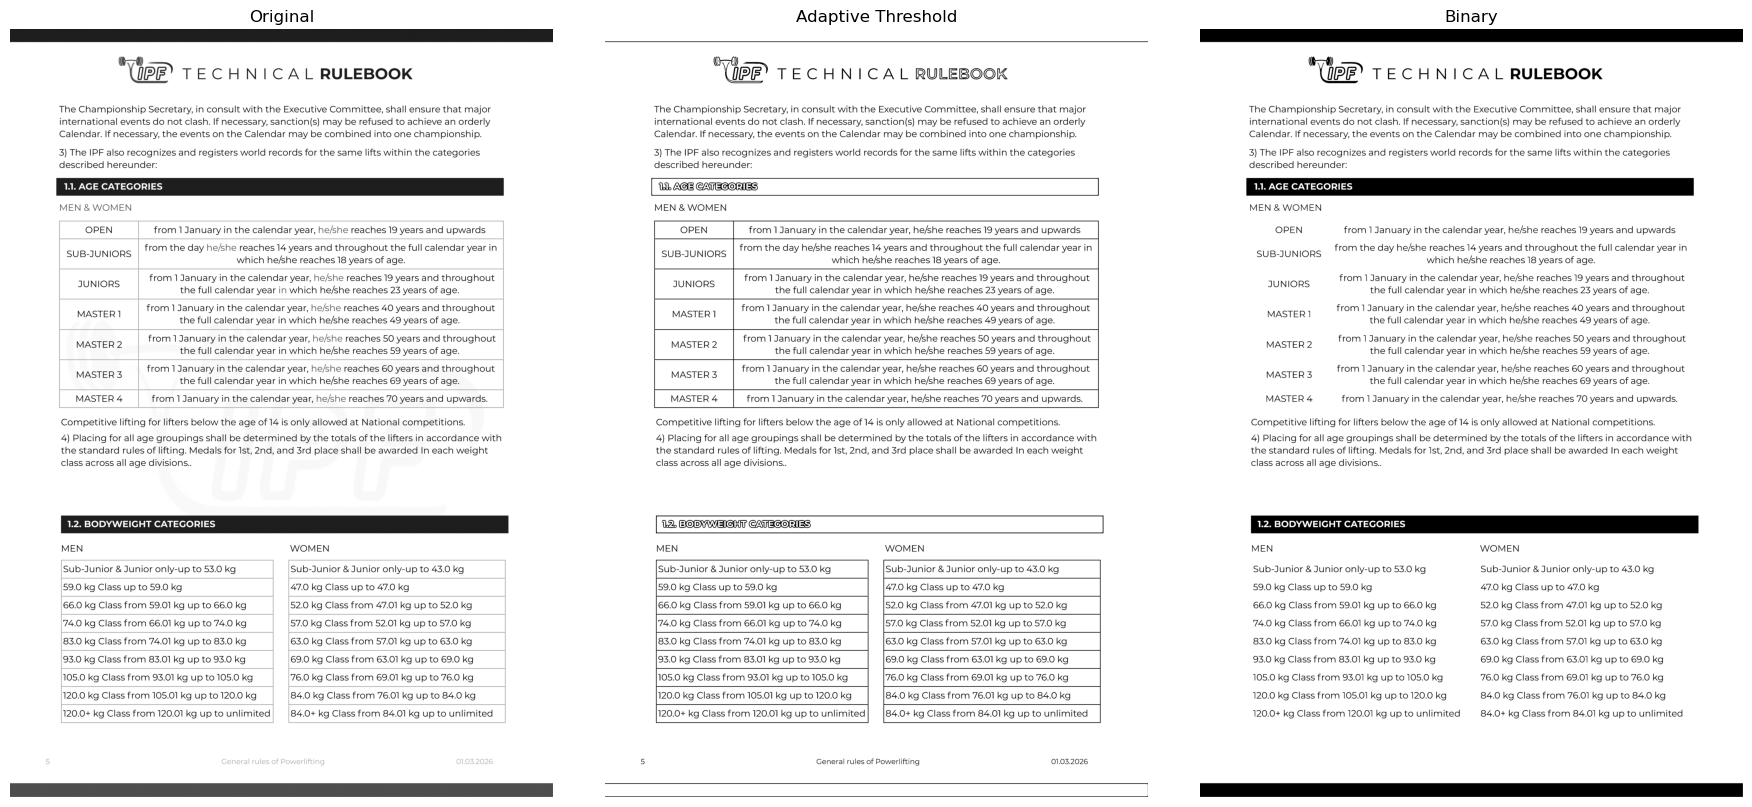

In [10]:
page_number = 5

# Original
img = np.array(selected_pages[page_number])
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Fixed binary threshold
ret, fixed_binary = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)

# Adaptive threshold
adaptive_binary = cv2.adaptiveThreshold(
    img_gray,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    31,
    20
)

ret,thresh3 = cv2.threshold(img_gray,127,255,cv2.THRESH_BINARY)

titles = ["Original", "Adaptive Threshold", "Binary"]
images = [img_gray, adaptive_binary, thresh3]

plt.figure(figsize=(18, 8))

for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i], fontsize=12)
    plt.axis("off")

plt.tight_layout()
plt.show()


### After investigation the standard thresholding was unsuitable for pages with tables and diagram pages, as it removed the table borders etc. Further experimentation was required, so the adaptive thresholding was found to be more suitable. 

In [11]:
# =========================================================================
# Apply selected threshold preprocessing to pages 4, 5, 10, 25 (not page 2)
# =========================================================================

# Pages to preprocess
threshold_page_numbers = [4, 5, 10, 25]

# Dictionary to store final preprocessed images
#preprocessed_pages = {}

# Dictionary to store method used, useful for later explanation
preprocessing_method_used = {}

for page_number in threshold_page_numbers:
    
    # Convert selected PDF page image to NumPy array
    img = np.array(selected_pages[page_number])
    
    # Convert image to grayscale
    img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    
    # Apply adaptive threshold
    adaptive_binary = cv2.adaptiveThreshold(
        img_gray,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        31,
        20
    )
    
    # Store the preprocessed image
    preprocessed_pages[page_number] = adaptive_binary

### One preprocessing approach didn't work equally well for all the different page layouts. The standard binary thresholding reduced the watermark on the simpler text-heavy pages, but weakened table borders and structured content. Adaptive thresholding preserved the table, mixed-content, and diagram-based pages better, although it slightly altered the appearance of the dark section headings. Therefore, preprocessing was selected based on page content and its display rather than applying one method to every page

In [12]:
#ensuring all preprocessed images are stored for the next phase
print(preprocessed_pages.keys())

dict_keys([2, 4, 5, 10, 25])


### Removing the "IPF" logo, as this will cause noise issues with OCR also
print the shape of the image, to get an idea of the size and then with trial and error paint a white square over the logo.
due to time constraints with the assignment this rudimentary option was the most suitable.

In [13]:
img = np.array(preprocessed_pages[2])
print(img.shape)  # prints (height, width, channels)

(7019, 4963)


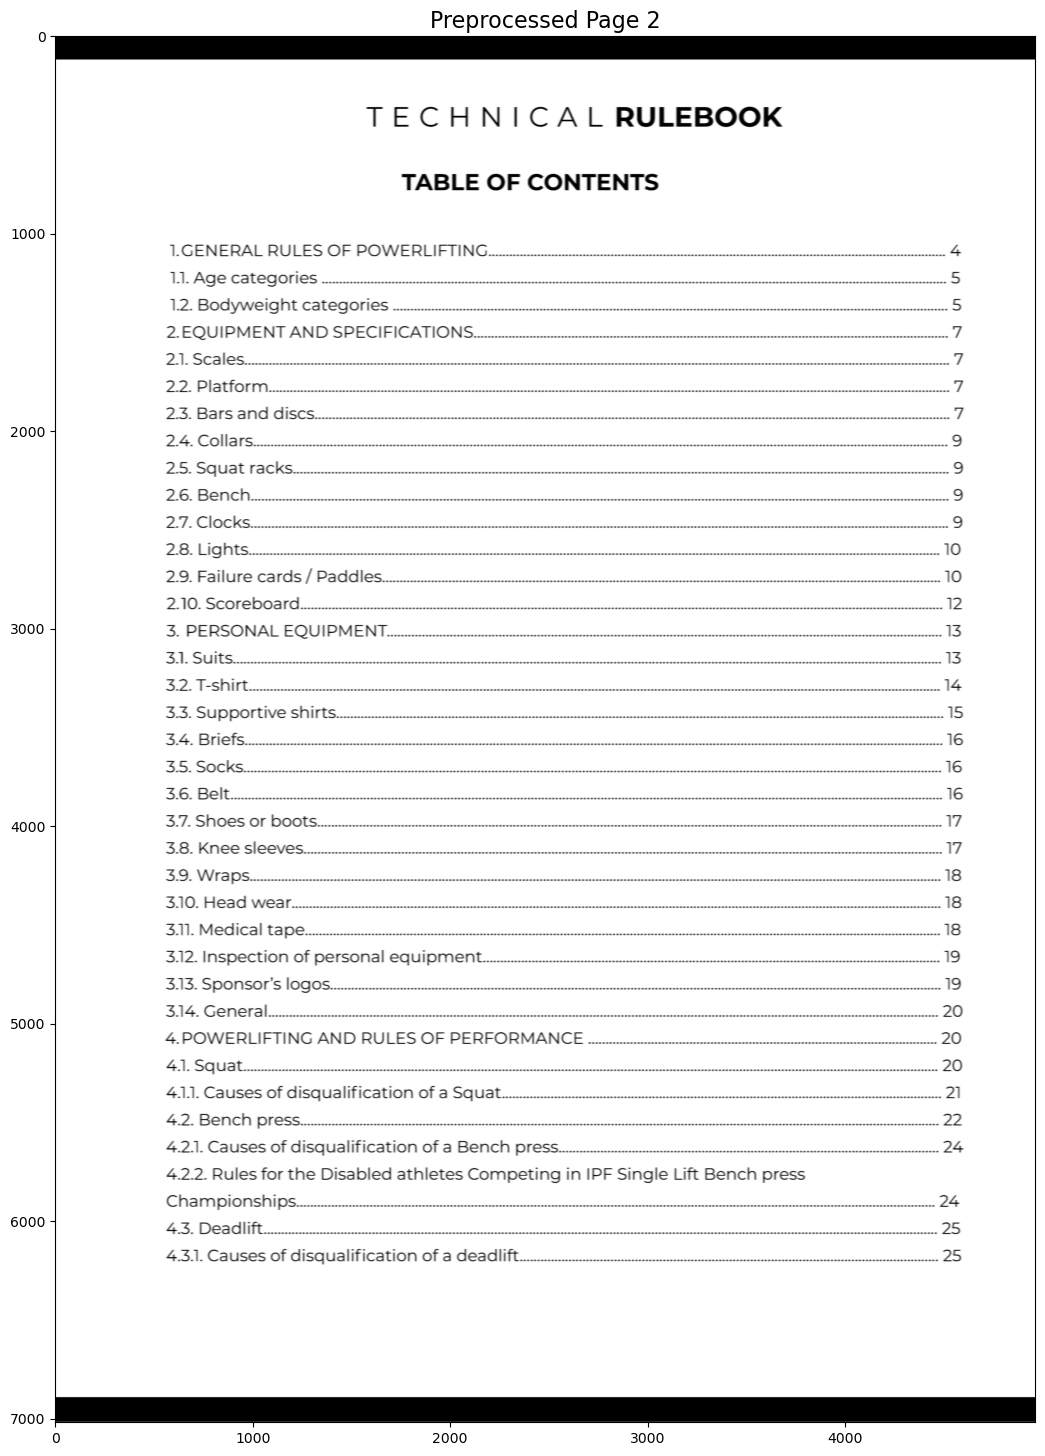

In [34]:
#the troublesome TOC page
page_number = 2

img2 = preprocessed_pages[page_number].copy()

#lab6a
cv2.rectangle(img2, (150, 150), (1500, 650), (255, 255, 255), -1) # draw white rectangle over logo area

plt.figure(figsize=(14, 18))
plt.imshow(img2, cmap="gray")
plt.title(f"Preprocessed Page {page_number}", fontsize=16)
plt.axis("on")
plt.show()

It worked, now apply to all images before OCR

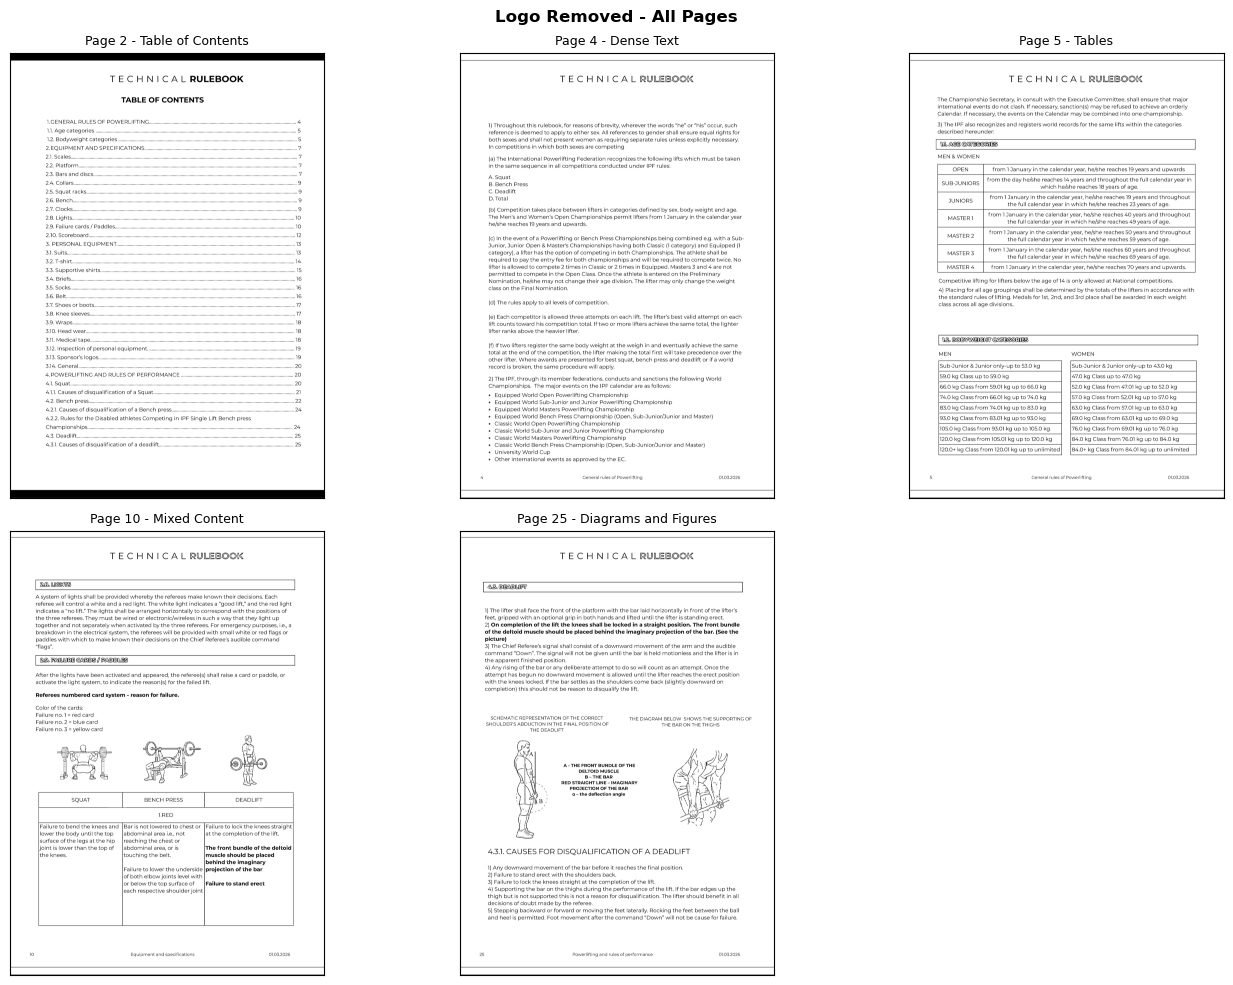

In [15]:
# Apply logo removal to all preprocessed pages

for page_number in PAGE_NUMBERS:
    img = preprocessed_pages[page_number].copy()
    cv2.rectangle(img, (150, 150), (1500, 650), (255, 255, 255), -1)  # paint white over logo area
    preprocessed_pages[page_number] = img

# Display all pages in a grid to verify logo removed
plt.figure(figsize=(14, 10))

for i, page_number in enumerate(PAGE_NUMBERS):
    plt.subplot(2, 3, i + 1)
    plt.imshow(preprocessed_pages[page_number], cmap="gray")
    plt.title(f"Page {page_number} - {PAGE_LABELS[page_number]}", fontsize=9)
    plt.xticks([])
    plt.yticks([])

plt.suptitle("Logo Removed - All Pages", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### The Table of Contents page required additional preprocessing because the dotted lines were being misread by Tesseract as random characters. A horizontal Gaussian blur was applied to merge/reduce these dotted patterns, which helped reduce OCR noise before text extraction.

** Important note here ** : The horizontal Gaussian blur was selected to reduce dotted leader line noise. Morphological closing could also be considered for a similar purpose, as it can connect nearby foreground components, mentioned in lab 6a.

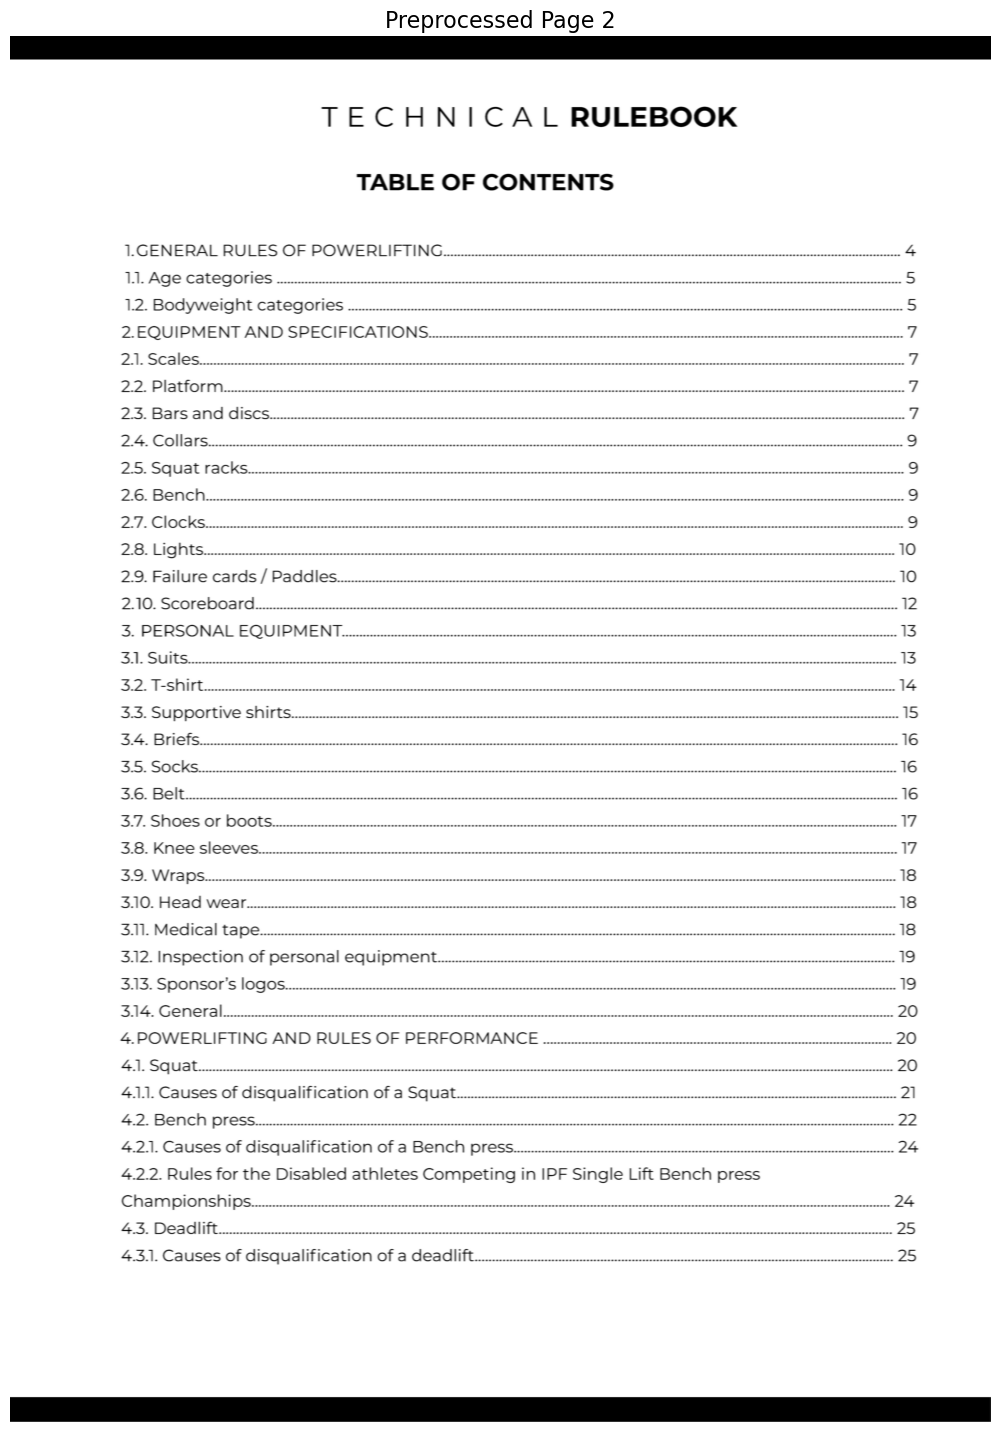

In [16]:
#the troublesome TOC page
page_number = 2

img = preprocessed_pages[page_number]
img = cv2.GaussianBlur(img, (21, 1), 0)
preprocessed_pages[page_number] = img

plt.figure(figsize=(14, 18))
plt.imshow(img, cmap="gray")
plt.title(f"Preprocessed Page {page_number}", fontsize=16)
plt.axis("off")
plt.show()

## Section 1b. OCR Text Extraction

In [17]:
# ============================================================
# OCR Text Extraction
# Extracts text from the preprocessed page images using Tesseract
# ============================================================
ocr_results = {}


# page_number = 2

# img = preprocessed_pages[page_number]
custom_config = r'--oem 1 --psm 12'

# # Get the preprocessed image from memory
# processed_img = preprocessed_pages[page_number]

# # Run OCR
# extracted_text = pytesseract.image_to_string(processed_img, config=custom_config)

# # Store extracted text
# ocr_results[page_number] = extracted_text
  
# experimenting with various versions of PSM setting for the troublesome TOC page

for page_number in PAGE_NUMBERS:
    print(f"Running OCR on Page {page_number} - {PAGE_LABELS[page_number]}...")

    # Get the preprocessed image from memory
    processed_img = preprocessed_pages[page_number]

    # Run OCR
    extracted_text = pytesseract.image_to_string(processed_img, config=custom_config)

    # Store extracted text
    ocr_results[page_number] = extracted_text

print("\nOCR extraction complete.")

Running OCR on Page 2 - Table of Contents...
Running OCR on Page 4 - Dense Text...
Running OCR on Page 5 - Tables...
Running OCR on Page 10 - Mixed Content...
Running OCR on Page 25 - Diagrams and Figures...

OCR extraction complete.


In [18]:
#print out the OCR'd pages

for page_number in PAGE_NUMBERS:
    print("=" * 80)
    print(f"Page {page_number} - {PAGE_LABELS[page_number]}")
    print("=" * 80)
    print(ocr_results[page_number])
    print("\n")

Page 2 - Table of Contents
a

TECHNICAL RULEBOOK

TABLE OF CONTENTS

1.GENERAL RULES OF POWERLIFTING

1.1. Age categories

12. Bodyweight categories

2.EQUIPMENT AND SPECIFICATIONS

2.1. Scales

2.2. Platform

2.5. Bars and discs

2.4. Collars

2.5. Squat racks

2.6. Bench

2.7. Clocks

2.8. Lights

10

2.9. Failure cards / Paddles

10

2.10. Scoreboard

12

3. PERSONAL EQUIPMEN Conn e nee nen ee cence eee eeceeeeececeeeeceseeeeceseeesecesecsecaeeessnsneeesensnessseesseseeaseeseatesseeeneeeeeeees 13

3.1. Suits

13

3.2. T-shirt

14

15

3.3. Supportive shirts

3.4. Briefs

16

3.5. Socks

16

3.6. Belt

16

4.7. Shoes or boots

17

3.8. Knee sleeves

17

18

3.9. Wraps

3.10. Head wear

18

3.11. Medical tape

18

3.12. Inspection of personal equipment

19

3.13. Sponsor's logos

19

3.14. General

20

4.POWERLIFTING AND RULES OF PERFORMANCE

20

20

4.|. Squat

21

4.|.). Causes of disqualification of a Squat

4.2. Bench press

22

4.2.|. Causes of disqualification of a Bench press



In [19]:
# ============================================================
# Clean OCR text before NLP
# Removes final known OCR noise from dotted leader lines
# ============================================================

cleaned_ocr_results = {}

ocr_noise_text = "e nee nen ee cence eee eeceeeeececeeeeceseeeeceseeesecesecsecaeeessnsneeesensnessseesseseeaseeseatesseeeneeeeeeee"

for page_number in PAGE_NUMBERS:
    text = ocr_results[page_number]

    # Remove the known OCR noise text
    text = text.replace(ocr_noise_text, "")

    cleaned_ocr_results[page_number] = text

print("OCR text cleaning complete.")

OCR text cleaning complete.


### Many Tesseract page segmentation modes were tested. --psm 12, sparse text with orientation and script detection, produced the best results for the selected pages. The Table of Contents page (2) produced poorer OCR output than the full text page. This was mainly due to the dotted lines between section headings and page numbers. Tesseract interpreted the dots as characters, resulting in noisy extracted text.

# Section 2. NLP

## Section 2a. Tokenise

In [20]:
# ============================================================
# Tokenise
# ============================================================

nlpDocs = {}

for page_number in PAGE_NUMBERS:
    print(f"Running NLP on Page {page_number} - {PAGE_LABELS[page_number]}...")

    # Get the OCR'd text from memory
    extracted_text = cleaned_ocr_results[page_number]

    # create doc object
    doc = nlp(extracted_text)

    # Store extracted text
    nlpDocs[page_number] = doc

print("\nTokenisation complete.")

Running NLP on Page 2 - Table of Contents...
Running NLP on Page 4 - Dense Text...
Running NLP on Page 5 - Tables...
Running NLP on Page 10 - Mixed Content...
Running NLP on Page 25 - Diagrams and Figures...

Tokenisation complete.


In [21]:
#get a sense of the document through spacy

page_number = 2

doc = nlpDocs[page_number]

#ca1 code came in handy here
for token in doc[:100]:
    print(f"{token.text} | {token.pos_} | {token.lemma_} | {token.dep_} | {token.is_stop}")

a | DET | a | det | True


 | SPACE | 

 | dep | False
TECHNICAL | PROPN | TECHNICAL | amod | False
RULEBOOK | NOUN | RULEBOOK | compound | False


 | SPACE | 

 | dep | False
TABLE | NOUN | table | ROOT | False
OF | ADP | of | prep | True
CONTENTS | NOUN | content | pobj | False


 | SPACE | 

 | dep | False
1.GENERAL | NUM | 1.general | nummod | False
RULES | NOUN | rule | appos | False
OF | ADP | of | prep | True
POWERLIFTING | VERB | powerlifte | pobj | False


 | SPACE | 

 | dep | False
1.1 | NUM | 1.1 | nummod | False
. | PUNCT | . | punct | False
Age | NOUN | age | compound | False
categories | NOUN | category | ROOT | False


 | SPACE | 

 | dep | False
12 | NUM | 12 | nummod | False
. | PUNCT | . | punct | False
Bodyweight | NOUN | bodyweight | compound | False
categories | NOUN | category | ROOT | False


 | SPACE | 

 | dep | False
2.EQUIPMENT | NUM | 2.equipment | amod | False
AND | CCONJ | and | cc | True
SPECIFICATIONS | VERB | specification | conj | False


 | SPACE | 


## Section 2b. Stopword removal and token cleaning

In [22]:
# ============================================================
# Stopword Removal and Basic Token Cleaning
# ============================================================

cleaned_tokens_by_page = {}

for page_number in PAGE_NUMBERS:
    doc = nlpDocs[page_number]
    cleaned_tokens = []

    for token in doc:
        # Skip stopwords such as "the", "and", "of"
        if token.is_stop:
            continue

        # Skip punctuation
        if token.is_punct:
            continue

        # Skip spaces and blank lines
        if token.is_space:
            continue

        # Skip numbers
        if token.like_num:
            continue

        # Skip very long OCR error tokens
        if len(token.text) > 20:
            continue

        # Add the cleaned token text
        cleaned_tokens.append(token.text.lower())

    cleaned_tokens_by_page[page_number] = cleaned_tokens

print("Stopword removal and basic token cleaning complete.")

Stopword removal and basic token cleaning complete.


In [23]:
page_number = 2

cleaned_tokens = cleaned_tokens_by_page[page_number]

for token in cleaned_tokens[:100]:
    print(token)

technical
rulebook
table
contents
1.general
rules
powerlifting
age
categories
bodyweight
categories
2.equipment
specifications
scales
platform
bars
discs
collars
squat
racks
bench
clocks
lights
failure
cards
paddles
scoreboard
personal
equipmen
conn
s
suits
t
shirt
supportive
shirts
briefs
socks
belt
shoes
boots
knee
sleeves
wraps
head
wear
medical
tape
inspection
personal
equipment
sponsor
logos
general
4.powerlifting
rules
performance
4.|
squat
4.|
causes
disqualification
squat
bench
press
4.2.|
causes
disqualification
bench
press
rules
disabled
athletes
competing
ipf
single
lift
bench
press
championships
deadlift
4.3.|
causes
disqualification
deadlift


## Section 2c. Lemmatise

In [24]:
# ============================================================
# Lemmatise
# Converts words to their base form
# Example: categories -> category, rules -> rule
# ============================================================

lemmas_by_page = {}

for page_number in PAGE_NUMBERS:
    doc = nlpDocs[page_number]
    lemmas = []

    for token in doc:
        # Skip stopwords
        if token.is_stop:
            continue

        # Skip punctuation
        if token.is_punct:
            continue

        # Skip spaces
        if token.is_space:
            continue

        # Skip numbers
        if token.like_num:
            continue

        # Skip very long OCR error tokens
        if len(token.text) > 20:
            continue

        # Add the lemma in lowercase
        lemmas.append(token.lemma_.lower())

    lemmas_by_page[page_number] = lemmas

print("Lemmatisation complete.")

Lemmatisation complete.


In [25]:
page_number = 2

for lemma in lemmas_by_page[page_number][:100]:
    print(lemma)

technical
rulebook
table
content
1.general
rule
powerlifte
age
category
bodyweight
category
2.equipment
specification
scale
platform
bar
disc
collar
squat
rack
bench
clock
light
failure
card
paddle
scoreboard
personal
equipmen
conn
s
suit
t
shirt
supportive
shirt
brief
sock
belt
shoe
boot
knee
sleeve
wrap
head
wear
medical
tape
inspection
personal
equipment
sponsor
logo
general
4.powerlifting
rule
performance
4.|
squat
4.|
cause
disqualification
squat
bench
press
4.2.|
cause
disqualification
bench
press
rule
disabled
athlete
compete
ipf
single
lift
bench
press
championships
deadlift
4.3.|
cause
disqualification
deadlift


Lemmatisation was applied after token cleaning. This converts words to their base form, for example "categories" becomes "category" and "rules" becomes "rule". This helps group related word forms together for later analysis. in a "real" pipeline both lemmatisation and stemming would not be used. Lemmatisation was selected for the final analysis because it keeps words in a readable dictionary form. Stemming was demonstrated briefly for comparison, but was not used in the final output because it can produce less readable word forms.

## Section 2d. Stemming

In [26]:
## for comparison to the lemmatisation - we will stem the words also
stemmer = PorterStemmer()

stems_by_page = {}

for page_number in PAGE_NUMBERS:
    stems = []

    for token in cleaned_tokens_by_page[page_number]:
        stem = stemmer.stem(token)
        stems.append(stem)

    stems_by_page[page_number] = stems

print("Stemming complete.")

Stemming complete.


## Section 2e. Lemmatisation and Stemming comparison

In [27]:
import pandas as pd

page_number = 2   # change page if needed

comparison_df = pd.DataFrame({
    "Cleaned Token": cleaned_tokens_by_page[page_number][:15],
    "Lemma": lemmas_by_page[page_number][:15],
    "Stem": stems_by_page[page_number][:15]
})

comparison_df

,Cleaned Token,Lemma,Stem
0,technical,technical,technic
1,rulebook,rulebook,rulebook
2,table,table,tabl
3,contents,content,content
4,1.general,1.general,1.gener
5,rules,rule,rule
6,powerlifting,powerlifte,powerlift
7,age,age,age
8,categories,category,categori
9,bodyweight,bodyweight,bodyweight


### The comparison shows some good examples that lemmatisation produces more readable base words than stemming. For example, "categories" becomes "category" using lemmatisation, while stemming reduces it to "categori". 

In [28]:
# ============================================================
# Word Frequency Analysis
# Counts the most common lemmatised words across the selected pages
# ============================================================

from collections import Counter
import pandas as pd

# Combine all lemmas from all pages into one list
all_lemmas = []

for page_number in PAGE_NUMBERS:
    all_lemmas.extend(lemmas_by_page[page_number])

# Count word frequency
word_frequency = Counter(all_lemmas)

# Convert to DataFrame for easier viewing
word_frequency_df = pd.DataFrame(
    word_frequency.most_common(20),
    columns=["Word", "Frequency"]
)

word_frequency_df

,Word,Frequency
0,kg,23
1,lifter,20
2,lift,14
3,bar,13
4,failure,12
5,shall,12
6,junior,12
7,world,12
8,championship,11
9,class,11


Word frequency analysis was applied to the lemmatised tokens to identify the most common terms across the selected rulebook pages. Lemmatised words were used so that related forms, such as "rules" and "rule", were grouped together. This helped highlight key terms in the document, such as competition, lifter, rule, equipment, squat, bench, and deadlift.

## Section 2f. Named Entity Recognition (NER) 

In [29]:
# ============================================================
# Named Entity Recognition
# Identifies named entities found in the OCR text
# ============================================================

entities_by_page = {}

for page_number in PAGE_NUMBERS:
    doc = nlpDocs[page_number]
    entities = []

    for ent in doc.ents:
        entities.append([ent.text, ent.label_])

    entities_by_page[page_number] = entities

print("Named Entity Recognition complete.")

Named Entity Recognition complete.


In [30]:
all_entities = []

for page_number in PAGE_NUMBERS:
    for ent_text, ent_label in entities_by_page[page_number]:
        all_entities.append([page_number, PAGE_LABELS[page_number], ent_text, ent_label])

entities_df = pd.DataFrame(
    all_entities,
    columns=["Page", "Page Type", "Entity", "Label"]
)

entities_df

,Page,Page Type,Entity,Label
0,2,Table of Contents,1.GENERAL,CARDINAL
1,2,Table of Contents,1.1,CARDINAL
2,2,Table of Contents,12,CARDINAL
3,2,Table of Contents,2.EQUIPMENT,GPE
4,2,Table of Contents,2.1,CARDINAL
...,...,...,...,...
156,25,Diagrams and Figures,2,CARDINAL
157,25,Diagrams and Figures,4,CARDINAL
158,25,Diagrams and Figures,4,CARDINAL
159,25,Diagrams and Figures,5,CARDINAL


The named entity results were mixed. spaCy identified many numerical references as CARDINAL entities, which is expected because the rulebook contains section numbers, page numbers, bodyweight categories, and competition values. However, some domain-specific terms such as "IPF", or "International Powerlifting Federation" were not consistently recognised as named entities. This shows that a general-purpose NLP model may not fully understand specialist sports terminology without custom training.

## Section 2g. (TF-IDF)
Ref.: https://www.geeksforgeeks.org/machine-learning/understanding-tf-idf-term-frequency-inverse-document-frequency/

Further explanation was required here

In [31]:
# ============================================================
# TF-IDF Keyword Analysis
# Identifies important terms on each selected page
# Lab3c_TextFeatureExtraction_TFIDF
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# after some work, tfidf expects each “document” to be a single string of text, not a list of separate words.
# so I must convert lemmatised tokens back into one text string per page
tfidf_documents = []

for page_number in PAGE_NUMBERS:
    page_text = " ".join(lemmas_by_page[page_number])
    tfidf_documents.append(page_text)

# Create TF-IDF model
vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(tfidf_documents)

# Get feature names / words
feature_names = vectorizer.get_feature_names_out()

# Store top TF-IDF words per page
tfidf_results = []

for i, page_number in enumerate(PAGE_NUMBERS):
    scores = tfidf_matrix[i].toarray()[0]

    # Pair words with scores
    word_scores = list(zip(feature_names, scores))

    # Sort by highest TF-IDF score
    word_scores = sorted(word_scores, key=lambda x: x[1], reverse=True)

    # Keep top 10
    top_words = word_scores[:10]

    for word, score in top_words:
        tfidf_results.append([
            page_number,
            PAGE_LABELS[page_number],
            word,
            round(score, 4)
        ])

tfidf_df = pd.DataFrame(
    tfidf_results,
    columns=["Page", "Page Type", "Keyword", "TF-IDF Score"]
)

tfidf_df

,Page,Page Type,Keyword,TF-IDF Score
0,2,Table of Contents,bench,0.3383
1,2,Table of Contents,cause,0.2537
2,2,Table of Contents,disqualification,0.2537
3,2,Table of Contents,press,0.2537
4,2,Table of Contents,squat,0.2537
5,2,Table of Contents,personal,0.2096
6,2,Table of Contents,shirt,0.2096
7,2,Table of Contents,rule,0.1772
8,2,Table of Contents,equipment,0.1691
9,2,Table of Contents,category,0.1404


### TF-IDF was used to identify words that were important to individual pages, rather than simply counting the most frequent words overall. 
This helped highlight page-specific keywords from the IPF rulebook. 

For example, the diagramd & figures pages contain words such as "lifter", "bar" and "position" indicating these words are relevant to instructional diagram explanations.

# Multi-modal

### This pipeline combines computer vision and NLP. The PDF pages from the Technical Rulebook document were first treated as images and processed using OpenCV techniques such as grayscale conversion, thresholding, adaptive thresholding, and Gaussian blur. The processed images were then passed to Tesseract OCR to extract text. The extracted text was then analysed using NLP techniques such as tokenisation, stopword removal, lemmatisation, stemming comparison, word frequency, named entity recognition, and TF-IDF.

### Diagrams and Figures

The diagrams and figures page was included to test how the OCR pipeline handled visual instructional content. This page was more difficult than dense text because the information was not presented as simple paragraphs. It included layout, spacing, visual structure, and diagram-based content.

If time allowed, further work could explore more advanced handling of diagram content, such as separating text from visual elements or possibly attempting to interpret the diagrams themselves.

Adaptive thresholding was used because it preserved visual structure better than fixed binary thresholding. However, OCR is limited on diagram-based pages because Tesseract can extract nearby text, but it does not understand the meaning of the diagram itself. This was an important limitation of the pipeline.

### This makes the workflow multi-modal because it moves from visual document data into text-based analysis.

# Final Output

### The final output of this notebook is a working OCR and NLP pipeline for selected pages of the IPF Technical Rulebook. The pipeline:

- loaded selected PDF pages as images
- applied image preprocessing to improve OCR quality
- extracted text using Tesseract OCR
- cleaned OCR noise before NLP processing
- tokenised the extracted text using spaCy
- removed stopwords, punctuation, spaces, numbers, and OCR artefacts
- compared lemmatisation and stemming
- produced word frequency results
- identified named entities
- used TF-IDF to identify page-specific keywords

### The results showed that dense text pages produced the best OCR output, while table of contents, table-based, and diagram-based pages required extra preprocessing. The main conclusion is that OCR quality depends heavily on document layout and preprocessing choices.